In [1]:
import glob
from pathlib import Path

import pandas as pd


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"
worker_concurrency = 2

files = sorted(glob.glob(files_pattern))

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    required_cols = {"frame_id", "time_seconds", "status"}

    # Nếu file không có header thì đọc lại theo 3 cột chuẩn
    if not required_cols.issubset(set(df.columns)):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["source_file"] = path.name
    df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce")
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
    df["status"] = df["status"].astype(str)

    df = df.dropna(subset=["frame_id", "time_seconds"])
    df["frame_id"] = df["frame_id"].astype(int)

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# 1. Toàn bộ CSV chạy được bao nhiêu FPS
total_frames = len(all_df)
total_time_seconds = all_df["time_seconds"].sum()
avg_all_time = all_df["time_seconds"].mean()
all_fps = total_frames / total_time_seconds if total_time_seconds > 0 else 0

# 2. Các frame đi qua consumer được bao nhiêu FPS
processed_df = all_df[all_df["status"] == "processed"]

processed_frames = len(processed_df)
processed_total_time = processed_df["time_seconds"].sum()
processed_avg_time = processed_df["time_seconds"].mean()
processed_equivalent_fps = (
    processed_frames / processed_total_time
    if processed_total_time > 0
    else 0
)

# 3. Ước lượng consumer 2 luồng
estimated_consumer_capacity_fps = (
    worker_concurrency / processed_avg_time
    if processed_avg_time and processed_avg_time > 0
    else 0
)

print("===== OVERALL REPORT =====")
print(f"Số file CSV                      : {len(files)}")
print(f"Tổng số frame                    : {total_frames}")
print(f"Tổng thời gian cộng dồn          : {total_time_seconds:.6f} giây")
print(f"Thời gian trung bình / frame     : {avg_all_time:.6f} giây")
print(f"FPS toàn bộ CSV                  : {all_fps:.3f} FPS")

print("\n===== PROCESSED FRAME REPORT =====")
print(f"Số frame qua consumer            : {processed_frames}")
print(f"Tổng thời gian processed cộng dồn: {processed_total_time:.6f} giây")
print(f"Thời gian TB / processed frame   : {processed_avg_time:.6f} giây")
print(f"Processed equivalent FPS         : {processed_equivalent_fps:.3f} FPS")

print("\n===== CONSUMER 2-LUỒNG ƯỚC LƯỢNG =====")
print(f"worker_concurrency               : {worker_concurrency}")
print(f"Estimated consumer capacity      : {estimated_consumer_capacity_fps:.3f} FPS")
print("Lưu ý: chỉ là ước lượng lý thuyết, không phải throughput thực tế nếu không có start/end timestamp.")

print("\n===== PER CAMERA =====")

summary_rows = []

for cam_id, g in all_df.groupby("cam_id"):
    g_processed = g[g["status"] == "processed"]

    cam_total_frames = len(g)
    cam_total_time = g["time_seconds"].sum()
    cam_avg_time = g["time_seconds"].mean()
    cam_all_fps = cam_total_frames / cam_total_time if cam_total_time > 0 else 0

    cam_processed_frames = len(g_processed)
    cam_processed_total_time = g_processed["time_seconds"].sum()
    cam_processed_avg_time = g_processed["time_seconds"].mean()

    cam_processed_fps = (
        cam_processed_frames / cam_processed_total_time
        if cam_processed_total_time > 0
        else 0
    )

    summary_rows.append({
        "cam_id": cam_id,
        "total_frames": cam_total_frames,
        "total_time_seconds": cam_total_time,
        "avg_time_seconds_per_frame": cam_avg_time,
        "all_frame_fps": cam_all_fps,
        "processed_frames": cam_processed_frames,
        "processed_total_time_seconds": cam_processed_total_time,
        "processed_avg_time_seconds_per_frame": cam_processed_avg_time,
        "processed_equivalent_fps": cam_processed_fps,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv("fps_summary_by_camera.csv", index=False)
all_df.to_csv("all_cameras_final_metrics.csv", index=False)

print("\nĐã ghi:")
print("- fps_summary_by_camera.csv")
print("- all_cameras_final_metrics.csv")

===== OVERALL REPORT =====
Số file CSV                      : 4
Tổng số frame                    : 114297
Tổng thời gian cộng dồn          : 7165.908529 giây
Thời gian trung bình / frame     : 0.062696 giây
FPS toàn bộ CSV                  : 15.950 FPS

===== PROCESSED FRAME REPORT =====
Số frame qua consumer            : 1154
Tổng thời gian processed cộng dồn: 262.743000 giây
Thời gian TB / processed frame   : 0.227680 giây
Processed equivalent FPS         : 4.392 FPS

===== CONSUMER 2-LUỒNG ƯỚC LƯỢNG =====
worker_concurrency               : 2
Estimated consumer capacity      : 8.784 FPS
Lưu ý: chỉ là ước lượng lý thuyết, không phải throughput thực tế nếu không có start/end timestamp.

===== PER CAMERA =====


,cam_id,total_frames,total_time_seconds,avg_time_seconds_per_frame,all_frame_fps,processed_frames,processed_total_time_seconds,processed_avg_time_seconds_per_frame,processed_equivalent_fps
0,1,28473,1767.800402,0.062087,16.106456,380,89.380,0.235211,4.251510
1,2,28608,1826.918860,0.063860,15.659152,267,56.997,0.213472,4.684457
2,3,28608,1805.535385,0.063113,15.844608,354,81.157,0.229257,4.361916
3,4,28608,1765.653882,0.061719,16.202496,153,35.209,0.230124,4.345480



Đã ghi:
- fps_summary_by_camera.csv
- all_cameras_final_metrics.csv


In [2]:
import pandas as pd

df = pd.read_csv(r"D:\haui_sict_fitness_score\recognize_block\frame_2_final_metrics.csv")

# Chuẩn hóa dữ liệu
df["status"] = df["status"].astype(str).str.strip()
df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")

# Lọc processed
processed_df = df[df["status"] == "processed"].copy()
processed_df

,frame_id,time_seconds,status
615,615,0.739,processed
620,620,0.448,processed
629,629,0.185,processed
633,633,0.170,processed
638,638,0.145,processed
...,...,...,...
26818,26818,0.250,processed
26821,26821,0.178,processed
26824,26824,0.181,processed
26839,26839,0.207,processed


In [3]:
total_time = processed_df["time_seconds"].sum()
total_time

56.99699999999999

In [4]:
for cam_id in ["1", "2", "3", "4"]:
    g = all_df[
        (all_df["cam_id"].astype(str) == cam_id)
        & (all_df["status"] == "processed")
    ].copy()

    print(f"\n===== CAM {cam_id} =====")
    print("frames:", len(g))
    print("sum:", g["time_seconds"].sum())
    print("mean:", g["time_seconds"].mean())
    print("median:", g["time_seconds"].median())
    print("p90:", g["time_seconds"].quantile(0.90))
    print("p95:", g["time_seconds"].quantile(0.95))
    print("p99:", g["time_seconds"].quantile(0.99))
    print("max:", g["time_seconds"].max())

    print("Top 10 slow frames:")
    print(
        g.sort_values("time_seconds", ascending=False)
        [["frame_id", "time_seconds", "status"]]
        .head(10)
    )


===== CAM 1 =====
frames: 380
sum: 89.38
mean: 0.23521052631578945
median: 0.2445
p90: 0.32020000000000004
p95: 0.3414000000000001
p99: 0.4877599999999968
max: 1.092
Top 10 slow frames:
       frame_id  time_seconds     status
16431     16431         1.092  processed
16436     16436         0.808  processed
451         451         0.688  processed
8391       8391         0.611  processed
2416       2416         0.455  processed
2425       2425         0.417  processed
457         457         0.414  processed
1169       1169         0.412  processed
2433       2433         0.405  processed
18454     18454         0.404  processed

===== CAM 2 =====
frames: 267
sum: 56.99699999999999
mean: 0.21347191011235953
median: 0.177
p90: 0.346
p95: 0.3797
p99: 0.5030199999999999
max: 0.739
Top 10 slow frames:
       frame_id  time_seconds     status
29088       615         0.739  processed
49218     20745         0.630  processed
39999     11526         0.505  processed
39091     10618         0.

Found files:
D:\haui_sict_fitness_score\recognize_block\frame_1_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_2_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_3_final_metrics.csv
D:\haui_sict_fitness_score\recognize_block\frame_4_final_metrics.csv
   cam_id  frames  median     p95      p99      mean    max  median_ms  \
0       1     380  0.2445  0.3414  0.48776  0.235211  1.092      244.5   
1       2     267  0.1770  0.3797  0.50302  0.213472  0.739      177.0   
2       3     354  0.2185  0.3497  0.49299  0.229257  0.818      218.5   
3       4     153  0.1900  0.4048  0.46176  0.230124  0.798      190.0   

   p95_ms  p99_ms  
0   341.4  487.76  
1   379.7  503.02  
2   349.7  492.99  
3   404.8  461.76  


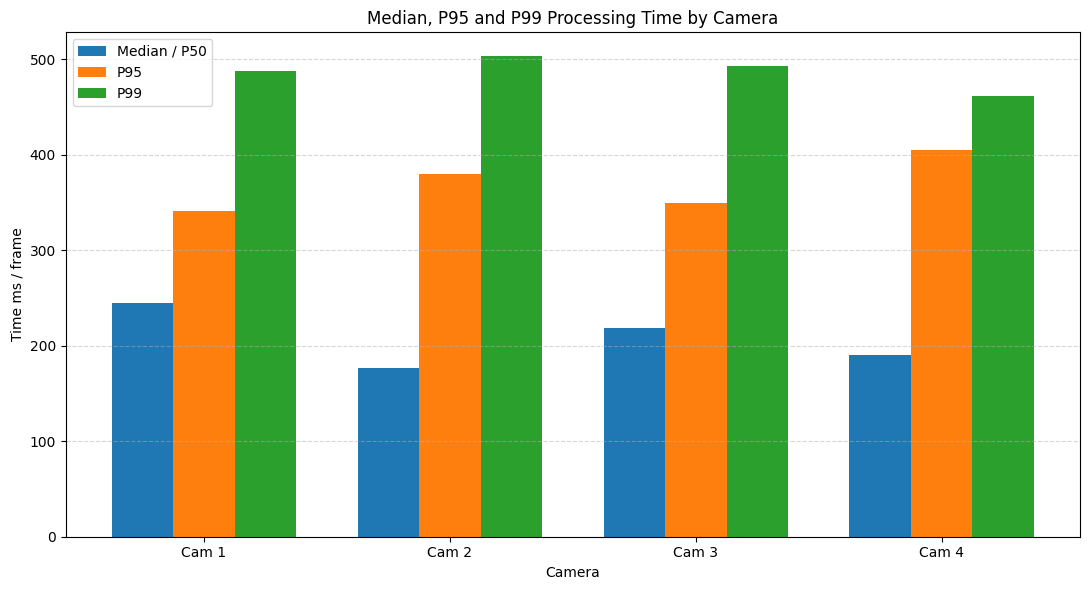

Saved chart to: D:\haui_sict_fitness_score\recognize_block\median_p95_p99_by_camera_ms.png


In [5]:
import glob
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"
files = sorted(glob.glob(files_pattern))

print("Found files:")
for f in files:
    print(f)

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    if not {"frame_id", "time_seconds", "status"}.issubset(df.columns):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["status"] = df["status"].astype(str).str.strip()
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Chỉ lấy các frame đi qua consumer
processed_df = all_df[all_df["status"] == "processed"].copy()

summary = (
    processed_df
    .groupby("cam_id")["time_seconds"]
    .agg(
        frames="count",
        median="median",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        mean="mean",
        max="max",
    )
    .reset_index()
)

summary["cam_id"] = summary["cam_id"].astype(int)
summary = summary.sort_values("cam_id")

summary["median_ms"] = summary["median"] * 1000
summary["p95_ms"] = summary["p95"] * 1000
summary["p99_ms"] = summary["p99"] * 1000

print(summary)

x = range(len(summary))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    [i - width for i in x],
    summary["median_ms"],
    width=width,
    label="Median / P50",
)

plt.bar(
    [i for i in x],
    summary["p95_ms"],
    width=width,
    label="P95",
)

plt.bar(
    [i + width for i in x],
    summary["p99_ms"],
    width=width,
    label="P99",
)

plt.xticks(x, [f"Cam {cam}" for cam in summary["cam_id"]])
plt.xlabel("Camera")
plt.ylabel("Time ms / frame")
plt.title("Median, P95 and P99 Processing Time by Camera")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

output_path = r"D:\haui_sict_fitness_score\recognize_block\median_p95_p99_by_camera_ms.png"
plt.savefig(output_path, dpi=200)

plt.show()

print(f"Saved chart to: {output_path}")

In [6]:
import glob
from pathlib import Path

import pandas as pd


files_pattern = r"D:\haui_sict_fitness_score\recognize_block\frame_*_final_metrics.csv"

thresholds = [0.2, 0.5, 1.0]

files = sorted(glob.glob(files_pattern))

if not files:
    raise FileNotFoundError(f"Không tìm thấy file theo pattern: {files_pattern}")

dfs = []

for file in files:
    path = Path(file)

    df = pd.read_csv(path)

    # Nếu file không có header thì đọc lại
    if not {"frame_id", "time_seconds", "status"}.issubset(df.columns):
        df = pd.read_csv(
            path,
            header=None,
            names=["frame_id", "time_seconds", "status"],
        )

    cam_id = path.name.replace("frame_", "").replace("_final_metrics.csv", "")

    df["cam_id"] = cam_id
    df["frame_id"] = pd.to_numeric(df["frame_id"], errors="coerce")
    df["time_seconds"] = pd.to_numeric(df["time_seconds"], errors="coerce")
    df["status"] = df["status"].astype(str).str.strip()

    df = df.dropna(subset=["frame_id", "time_seconds"])
    df["frame_id"] = df["frame_id"].astype(int)

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

processed_df = all_df[all_df["status"] == "processed"].copy()

summary_rows = []

for cam_id, g in processed_df.groupby("cam_id"):
    total = len(g)

    row = {
        "cam_id": cam_id,
        "processed_frames": total,
        "total_time_seconds": g["time_seconds"].sum(),
        "mean_seconds": g["time_seconds"].mean(),
        "median_seconds": g["time_seconds"].median(),
        "p95_seconds": g["time_seconds"].quantile(0.95),
        "p99_seconds": g["time_seconds"].quantile(0.99),
        "max_seconds": g["time_seconds"].max(),
    }

    row["fps_by_mean"] = 1 / row["mean_seconds"] if row["mean_seconds"] > 0 else 0
    row["fps_by_median"] = 1 / row["median_seconds"] if row["median_seconds"] > 0 else 0

    for threshold in thresholds:
        count_fast = (g["time_seconds"] <= threshold).sum()
        ratio_fast = count_fast / total * 100 if total > 0 else 0

        col_prefix = str(threshold).replace(".", "_")
        row[f"frames_le_{col_prefix}s"] = count_fast
        row[f"percent_le_{col_prefix}s"] = ratio_fast

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df["cam_id"] = summary_df["cam_id"].astype(int)
summary_df = summary_df.sort_values("cam_id")

# In kết quả dễ đọc
for _, row in summary_df.iterrows():
    print(f"\n===== CAM {int(row['cam_id'])} =====")
    print(f"Processed frames : {int(row['processed_frames'])}")
    print(f"Mean             : {row['mean_seconds']:.6f}s")
    print(f"Median           : {row['median_seconds']:.6f}s")
    print(f"P95              : {row['p95_seconds']:.6f}s")
    print(f"P99              : {row['p99_seconds']:.6f}s")
    print(f"Max              : {row['max_seconds']:.6f}s")
    print(f"FPS by mean      : {row['fps_by_mean']:.3f}")
    print(f"FPS by median    : {row['fps_by_median']:.3f}")

    for threshold in thresholds:
        col_prefix = str(threshold).replace(".", "_")
        count_col = f"frames_le_{col_prefix}s"
        percent_col = f"percent_le_{col_prefix}s"

        print(
            f"<= {threshold}s        : "
            f"{int(row[count_col])}/{int(row['processed_frames'])} "
            f"({row[percent_col]:.2f}%)"
        )

output_path = r"D:\haui_sict_fitness_score\recognize_block\processed_latency_summary.csv"
summary_df.to_csv(output_path, index=False)

print(f"\nSaved summary to: {output_path}")


===== CAM 1 =====
Processed frames : 380
Mean             : 0.235211s
Median           : 0.244500s
P95              : 0.341400s
P99              : 0.487760s
Max              : 1.092000s
FPS by mean      : 4.252
FPS by median    : 4.090
<= 0.2s        : 161/380 (42.37%)
<= 0.5s        : 376/380 (98.95%)
<= 1.0s        : 379/380 (99.74%)

===== CAM 2 =====
Processed frames : 267
Mean             : 0.213472s
Median           : 0.177000s
P95              : 0.379700s
P99              : 0.503020s
Max              : 0.739000s
FPS by mean      : 4.684
FPS by median    : 5.650
<= 0.2s        : 181/267 (67.79%)
<= 0.5s        : 263/267 (98.50%)
<= 1.0s        : 267/267 (100.00%)

===== CAM 3 =====
Processed frames : 354
Mean             : 0.229257s
Median           : 0.218500s
P95              : 0.349700s
P99              : 0.492990s
Max              : 0.818000s
FPS by mean      : 4.362
FPS by median    : 4.577
<= 0.2s        : 166/354 (46.89%)
<= 0.5s        : 350/354 (98.87%)
<= 1.0s        :